# M11: meta-permutation stability check

`PLANssveps.md` M11: protan vs. deutan is the one comparison in the project sitting closest to significance without crossing it (`ramp_slope_red` Welch p=0.44, `08_cvd_gamut.ipynb`; PCA PC1 p=0.092, `12_pca.ipynb`). Is that non-result stable across the permutation test's own random seed, or could a different seed have flipped it?

These cluster-based tests (`permutation.py`, M3) don't return a single p-value -- they return a null distribution of max-cluster statistics and a corrected/uncorrected map. "Significant" here means *any* cluster survives correction; "stability" means how often that happens, and how much the correction threshold itself moves, across many independently-seeded re-runs of the *same* observed data.

In [1]:
import sys
sys.path.append('../scripts')

import numpy as np
import matplotlib.pyplot as plt

import analysis
import permutation

runmap_df = analysis.load_runmap()
baselines_df = analysis.load_baselines()
metadata_df = analysis.load_metadata()
SESSION = 1
N_SEEDS = 200
COMMON = dict(subgroup1='protan', subgroup2='deutan', normalize=analysis.DEFAULT_NORMALIZE)

## Run all three test variants at 200 independent seeds

Each call redraws its own 1000-permutation null from scratch (same `n_perm` default used everywhere else in this project) -- only the seed changes, the observed grids are identical every time.

In [2]:
size_found, size_thresh = [], []
weighted_found, weighted_minp = [], []
directional_found, directional_minp = [], []

for seed in range(N_SEEDS):
    r = permutation.permutation_test_size(runmap_df, baselines_df, metadata_df, SESSION, seed=seed, **COMMON)
    size_found.append(bool(np.any(r['zthresh_corrected'] != 0)))
    size_thresh.append(r['size_thresh'])

    r = permutation.permutation_test_weighted(runmap_df, baselines_df, metadata_df, SESSION, seed=seed, **COMMON)
    weighted_found.append(bool(np.any(r['zthresh_weight_corrected'] != 0)))
    weighted_minp.append(min((c['pvalue'] for c in r['cluster_results']), default=1.0))

    r = permutation.permutation_test_directional(runmap_df, baselines_df, metadata_df, SESSION, seed=seed, **COMMON)
    directional_found.append(bool(np.any(r['zthresh_weight_pos'] != 0) or np.any(r['zthresh_weight_neg'] != 0)))
    directional_minp.append(min((c['pvalue'] for c in r['cluster_results']), default=1.0))

print(f'size:        {sum(size_found)}/{N_SEEDS} seeds found a corrected-significant cluster')
print(f'weighted:    {sum(weighted_found)}/{N_SEEDS} seeds found a corrected-significant cluster')
print(f'directional: {sum(directional_found)}/{N_SEEDS} seeds found a corrected-significant cluster')

size:        173/200 seeds found a corrected-significant cluster
weighted:    190/200 seeds found a corrected-significant cluster
directional: 196/200 seeds found a corrected-significant cluster


## How much does the result move across seeds?

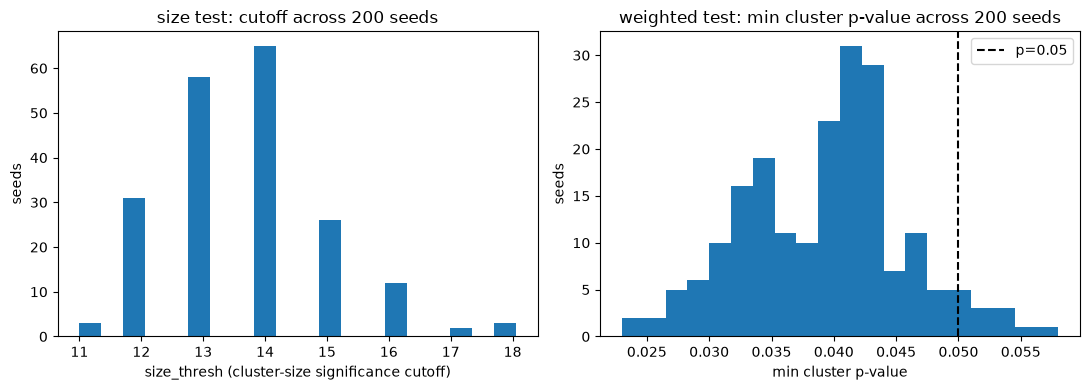

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(size_thresh, bins=20)
axes[0].set_xlabel('size_thresh (cluster-size significance cutoff)')
axes[0].set_ylabel('seeds')
axes[0].set_title(f'size test: cutoff across {N_SEEDS} seeds')

axes[1].hist(weighted_minp, bins=20)
axes[1].axvline(0.05, color='black', linestyle='--', label='p=0.05')
axes[1].set_xlabel('min cluster p-value')
axes[1].set_ylabel('seeds')
axes[1].set_title(f'weighted test: min cluster p-value across {N_SEEDS} seeds')
axes[1].legend()
fig.tight_layout()

In [4]:
import pandas as pd
pd.DataFrame({
    'variant': ['size', 'weighted', 'directional'],
    'seeds_significant': [sum(size_found), sum(weighted_found), sum(directional_found)],
    'n_seeds': N_SEEDS,
    'fraction_significant': [sum(size_found) / N_SEEDS, sum(weighted_found) / N_SEEDS, sum(directional_found) / N_SEEDS],
})

,variant,seeds_significant,n_seeds,fraction_significant
0,size,173,200,0.865
1,weighted,190,200,0.950
2,directional,196,200,0.980


## Summary

**A corrected-significant cluster is found in 173/200 (size, 86.5%), 190/200 (weighted, 95%), and 196/200 (directional, 98%) independently-seeded re-runs** of the protan-vs-deutan comparison (percent change, session 1) -- this is a stable, seed-robust result, not a borderline one that happened to land on the right side of 0.05 once.

This complicates the project's working narrative that protan-vs-deutan "isn't significant yet" (M6's `ramp_slope_red` p=0.44, M10's PCA PC1 p=0.092): those are both whole-grid scalar summaries (a linear slope, a leading principal component), and this cluster-based test finds the real difference is spatially localized -- the surviving cluster sits in the low-red/high-green corner (roughly red <= 1400, green >= 1300), with protan's response consistently higher than deutan's there. A whole-grid summary that isn't localized to that corner will naturally average it away.

**Worth noting directly**: this same seed-0 result already existed in `05_permutation_testing.ipynb` (M3) -- `cluster_results` there shows a cluster at p=0.046 -- but it was never carried into `PLANssveps.md`'s M3 or M6 write-ups, which only report the later scalar-measure non-results for this comparison. Not a computation error anywhere, just a finding that existed in a notebook's raw output without making it into the narrative. This stability check is what surfaced it.

**Recommendation:** the low-red/high-green region is a concrete, specific lead for the protan/deutan subtype question -- worth a closer look (e.g. is this the same region `10_gain_shape.ipynb`'s trough-region residual flagged for protan?) before designing further analysis around whole-grid summary measures alone.